# GaussiaNB from scratch

In [24]:
# pip install seaborn
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 11.5 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import confusion_matrix

In [9]:
df = pd.read_csv("data/breast-cancer.csv")
df.head(10)
#diagnosis is a label, M = malignant, B = benign

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


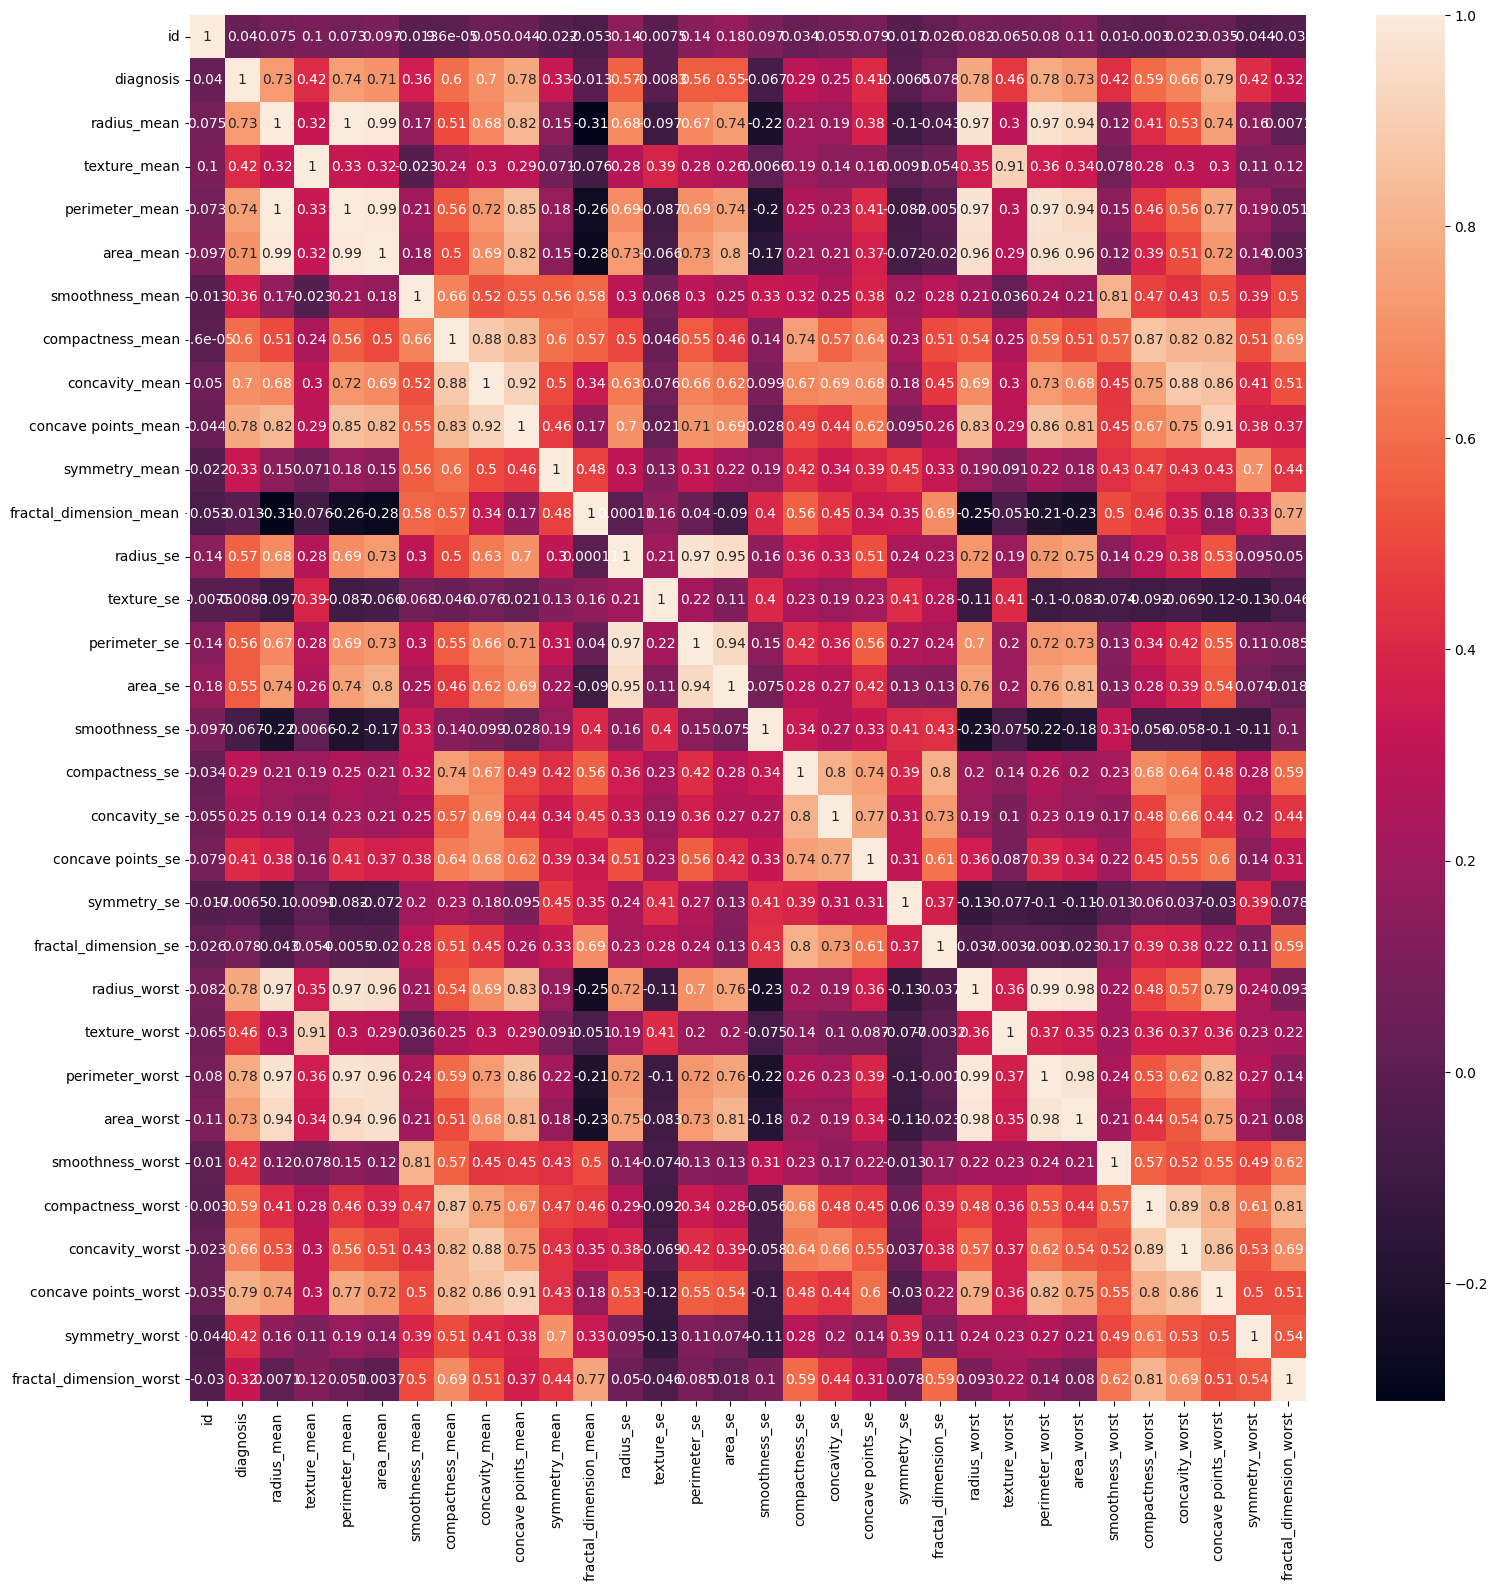

In [84]:
##correlation analysis

label_map = { #categorical label no mater what the value is as long as they are unique/distinguished
    'M':1,
    'B':0
}

label_df = df.copy()
label_df.drop('id',axis=1)

label_df["diagnosis"] = df['diagnosis'].map(lambda x: label_map[x])
label_df = label_df.astype('float')


correlation = label_df.corr()

plt.figure(figsize=(18,18)) #create a figure
sns.heatmap(correlation, annot = True)
plt.show()

In [71]:
#data split into train and test
train, test = train_test_split(label_df, random_state=42, test_size=0.2)
train , test, len(train), len(test)

(             id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
 68     859471.0        0.0        9.029         17.33           58.79   
 181    873593.0        1.0       21.090         26.57          142.70   
 63     859196.0        0.0        9.173         13.86           59.20   
 248  88466802.0        0.0       10.650         25.22           68.01   
 60     858970.0        0.0       10.170         14.88           64.55   
 ..          ...        ...          ...           ...             ...   
 71     859711.0        0.0        8.888         14.64           58.79   
 106    863031.0        0.0       11.640         18.33           75.17   
 270   8910721.0        0.0       14.290         16.82           90.30   
 435    908489.0        1.0       13.980         19.62           91.12   
 102    862965.0        0.0       12.180         20.52           77.22   
 
      area_mean  smoothness_mean  compactness_mean  concavity_mean  \
 68       250.5          0.10660        

In [85]:
y_train = train['diagnosis']
x_train = train.drop(columns='diagnosis') #x_train = train.drop('diagnosis', axis=1) default=0

y_test = test['diagnosis']
x_test = test.drop(columns='diagnosis') 

x_test,x_train,y_test,y_train

(             id  radius_mean  texture_mean  perimeter_mean  area_mean  \
 204     87930.0        12.47         18.60           81.09      481.9   
 70     859575.0        18.94         21.31          123.60     1130.0   
 131      8670.0        15.46         19.48          101.70      748.9   
 431    907915.0        12.40         17.68           81.47      467.8   
 540    921385.0        11.54         14.44           74.65      402.9   
 ..          ...          ...           ...             ...        ...   
 486    913102.0        14.64         16.85           94.21      666.0   
 75    8610404.0        16.07         19.65          104.10      817.7   
 249    884689.0        11.52         14.93           73.87      406.3   
 238    883270.0        14.22         27.85           92.55      623.9   
 265  88995002.0        20.73         31.12          135.70     1419.0   
 
      smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
 204          0.09965         

In [37]:
# # GaussianNB
# gnb = GaussianNB()
# #train
# gnb_model = gnb.fit(X=x_train,y=y_train)


# gnb_model.classes_, gnb_model.epsilon_, gnb_model.feature_names_in_ ,gnb_model.theta_ , gnb_model.var_

(array([0, 1]),
 17522474.53449407,
 array(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
        'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
        'radius_se', 'texture_se', 'perimeter_se', 'area_se',
        'smoothness_se', 'compactness_se', 'concavity_se',
        'concave points_se', 'symmetry_se', 'fractal_dimension_se',
        'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
        'smoothness_worst', 'compactness_worst', 'concavity_worst',
        'concave points_worst', 'symmetry_worst',
        'fractal_dimension_worst'], dtype=object),
 array([[2.68145987e+07, 1.21680559e+01, 1.78216434e+01, 7.82140909e+01,
         4.64910839e+02, 9.17334615e-02, 7.98258741e-02, 4.72053007e-02,
         2.55395140e-02, 1.73751049e-01, 6.28359790e-02, 2.84577273e-01,
         1.20402867e+00, 2.01659545e+00, 2.13169266e+01, 7.12550350e-03,
         2.20011573e-02, 


![image](./wechat_2025-07-13_130032_145.png)

In [40]:
# y_pred = gnb_model.predict(x_test)
# cm = confusion_matrix(y_test, y_pred)
# print(cm)


[[70  1]
 [43  0]]


In [89]:
class MyGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.smoothing = var_smoothing
        
    def fit(self, X, y):
        X =  np.asarray(X,dtype = float)

        #get classes
        value_count = y.value_counts()
        self.classes = value_count.index.tolist()
        print(self.classes)

        #get prior prob
        self.prior = {}
        for cla in self.classes:
            self.prior[cla] = value_count[cla]/y.count()
        print(f"prior probability is {self.prior}")

        self.class_mean_ = {}
        self.class_var_ = {}

        #get likelihood  
        for c in self.classes:
            X_c = X[y == c]  #select all samples of c category 
            self.class_mean_[c] = np.mean(X_c,axis=0) #axis = 0 means column compute
            self.class_var_[c] = np.var(X_c,axis=0)

        return self


    #get Gaussian pdf
    def gaussian_pdf(self, x, mean, var):
        var_smoothing = 1e-9 # in case divided by zero
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + var_smoothing)
        exponent = np.exp(- (x - mean) ** 2 / (2 * var + var_smoothing))
        return coeff * exponent



    def predict(self, X):
        X =  np.asarray(X,dtype = float)
        predictions = []

        for row_features in X:
            posteriors = []

            for c in self.classes:
                prior = np.log(self.prior[c])

                likelihood = np.sum(np.log(self.gaussian_pdf(row_features, self. class_mean_[c], self.class_var_[c])))

                #get posteriors
                posterior = prior + likelihood
                posteriors.append(posterior)

            predictions.append(self.classes[np.argmax(posteriors)])
            
        return predictions 
                


    def evaluation(self):#accuracy, confusion matrix
        pass

In [90]:
myNB = MyGaussianNB()
my_model = myNB.fit(X=x_train,y=y_train)

y_pred =  my_model.predict(x_test)
y_pred

[0.0, 1.0]
prior probability is {0.0: 0.6285714285714286, 1.0: 0.37142857142857144}


[0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0]

In [ ]:
y_pred = gnb_model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)